# Glacial Lake Segmentation: DeepLabV3+ (ResNet50) on Sentinel-2 false-colour tiles

**Changes vs. v1 (review fixes)**
- Honest naming: this is a DeepLabV3+-style model (not a U-Net), and it segments lakes, it does not predict GLOFs.
- Keras-correct ResNet50 preprocessing (caffe-style) is now *inside* the model; the loader feeds raw 0-255 RGB.
- Backbone taps are now block outputs (`conv4_block6_out`, `conv2_block3_out`); ASPP rates fit a 25x25 map; bilinear upsampling; output conv has a bias.
- Loss = BCE + Dice. Metrics are thresholded and dataset-level (`BinaryIoU`, `Precision`, `Recall`).
- Two-phase training (frozen backbone, then fine-tune at 1e-4), best-checkpoint saving to Drive, EarlyStopping, ReduceLROnPlateau.
- Online augmentation (train only) instead of offline copies; `PyDataset` instead of a one-shot generator; PyTorch dependency removed.
- Image/mask pairing is asserted by filename stem; seeds are set; splits are saved to Drive.
- Test set is actually evaluated, with a threshold tuned on val and a fair NDWI baseline on the same test split.
- Removed Grad-CAM (it was indexing the wrong axis for a 1-channel segmentation output).

**TODO before trusting the numbers:** define `group_key()` in the split cell so tiles from the same lake/scene stay in the same split.

In [1]:
!pip install albumentations -q

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


# Imports & config

In [3]:
import warnings
warnings.filterwarnings("ignore")

import json, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2

import tensorflow as tf
from tensorflow.keras import Input, Model, Sequential
from tensorflow.keras.layers import (Layer, Conv2D, BatchNormalization, ReLU, AveragePooling2D,
                                     UpSampling2D, Concatenate, Dropout, Activation)
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

import albumentations as A
from sklearn.model_selection import GroupShuffleSplit
from skimage.filters import threshold_otsu

# ---- Config ----
SEED       = 42
IMAGE_SIZE = 400
BATCH_SIZE = 16
DATA_DIR   = Path('/content/drive/MyDrive/data/')
IMG_DIR    = DATA_DIR / 'images'
MASK_DIR   = DATA_DIR / 'masks'
MODEL_DIR  = Path('/content/drive/MyDrive/model')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Seeds python, numpy and TF in one call
tf.keras.utils.set_random_seed(SEED)
print('GPUs:', tf.config.list_physical_devices('GPU'))

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Utils

In [4]:
def load_image(path):
    return np.array(Image.open(path).convert('RGB'))

def load_mask(path):
    # Binarize: any non-zero pixel = water
    return (np.array(Image.open(path).convert('L')) > 127).astype(np.float32)

def compute_ndwi(img):
    """NDWI from a false-colour image (channels: NIR, Red, Green)."""
    img = img.astype(np.float32) / 255.0
    nir, green = img[:, :, 0], img[:, :, 2]
    return (green - nir) / (green + nir + 1e-8)

def ndwi_to_mask(ndwi, threshold=0.0):
    return (ndwi > threshold).astype(np.float32)

def compute_metrics(pred, target):
    """Per-image IoU / Precision / Recall / F1 on HARD (binary) masks."""
    pred, target = pred.flatten().astype(np.float64), target.flatten().astype(np.float64)
    tp = (pred * target).sum()
    fp = (pred * (1 - target)).sum()
    fn = ((1 - pred) * target).sum()
    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    iou       = tp / (tp + fp + fn + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)
    return {'IoU': iou, 'Precision': precision, 'Recall': recall, 'F1': f1}

# Data exploration

In [5]:
img_paths  = sorted(IMG_DIR.glob('*.png'))
mask_paths = sorted(MASK_DIR.glob('*.png'))
print(f'Images found: {len(img_paths)} | Masks found: {len(mask_paths)}')

# Pairing is by sorted order, so make sure the names actually match
assert len(img_paths) > 0 and len(img_paths) == len(mask_paths), 'image/mask count mismatch'
bad = [(i.name, m.name) for i, m in zip(img_paths, mask_paths) if i.stem != m.stem]
assert not bad, f'image/mask name mismatch, e.g. {bad[:3]}'

# All tiles must already be IMAGE_SIZE x IMAGE_SIZE
shapes = {load_image(p).shape[:2] for p in img_paths}
assert shapes == {(IMAGE_SIZE, IMAGE_SIZE)}, f'unexpected tile sizes: {shapes}'

Images found: 410 | Masks found: 410


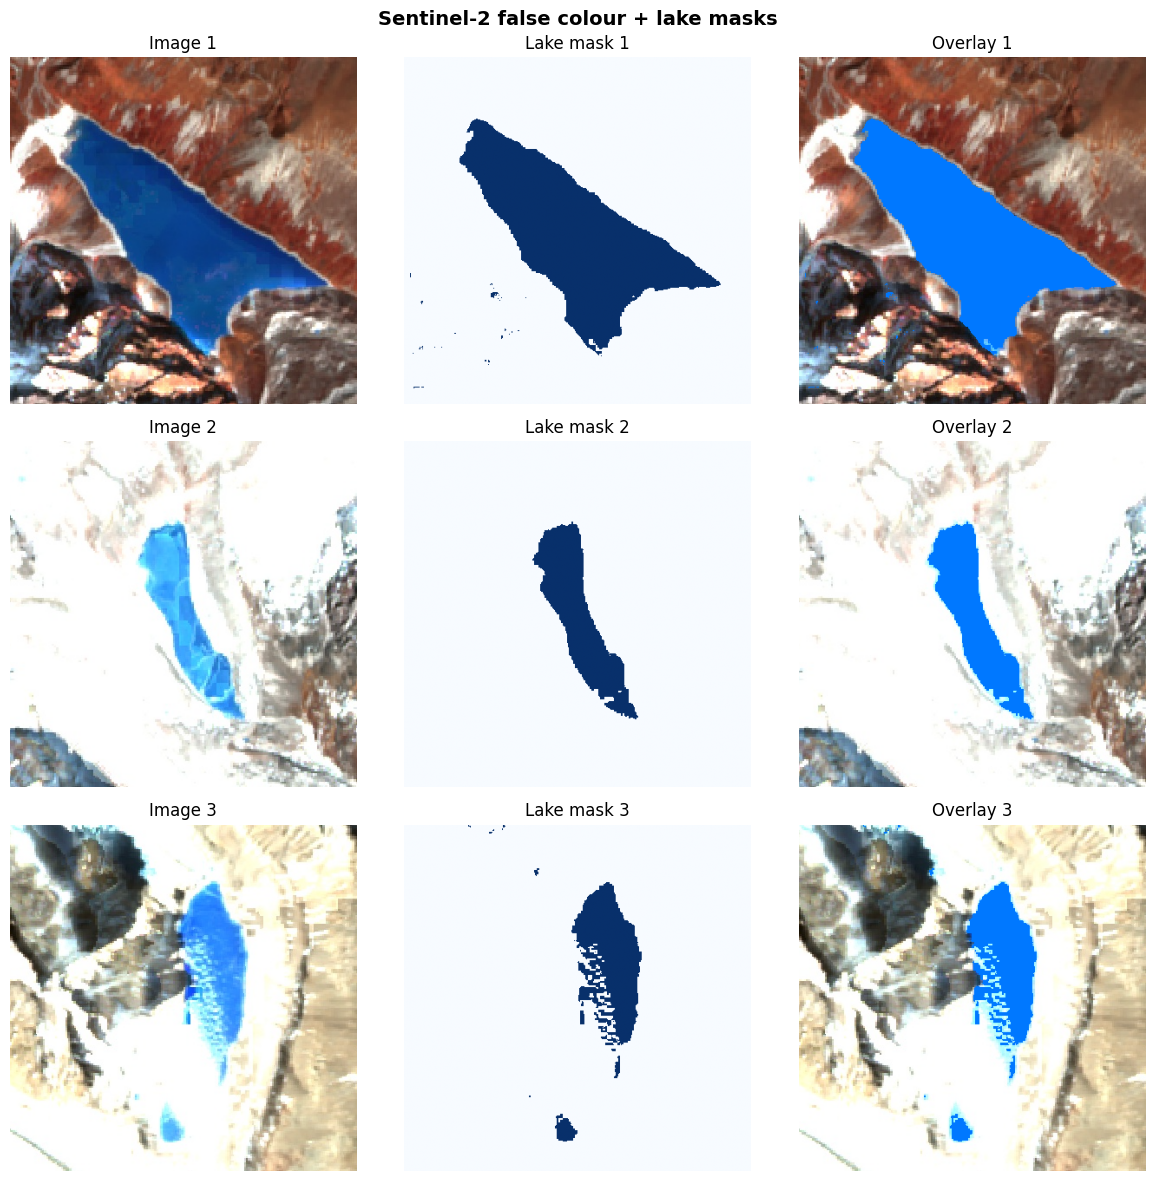

Total images:           410
Avg / max / min water:  13.26% / 39.95% / 1.78%
Images with >10% water: 252


In [6]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle('Sentinel-2 false colour + lake masks', fontsize=14, fontweight='bold')
for i, ax_row in enumerate(axes):
    img, mask = load_image(img_paths[i]), load_mask(mask_paths[i])
    ax_row[0].imshow(img);                ax_row[0].set_title(f'Image {i+1}')
    ax_row[1].imshow(mask, cmap='Blues'); ax_row[1].set_title(f'Lake mask {i+1}')
    overlay = img.copy(); overlay[mask == 1] = [0, 120, 255]
    ax_row[2].imshow(overlay);            ax_row[2].set_title(f'Overlay {i+1}')
    for a in ax_row: a.axis('off')
plt.tight_layout(); plt.show()

water_pct = np.array([load_mask(mp).mean() * 100 for mp in mask_paths])
print(f'Total images:           {len(img_paths)}')
print(f'Avg / max / min water:  {water_pct.mean():.2f}% / {water_pct.max():.2f}% / {water_pct.min():.2f}%')
print(f'Images with >10% water: {(water_pct > 10).sum()}')

# Split (train / val / test)

In [7]:
def group_key(path):
    """TODO: return an ID shared by all tiles of the same lake / scene / region.
    Until you do, this falls back to one group per image (a plain random split),
    which can leak near-duplicate tiles across train/val/test."""
    return path.stem

groups = np.array([group_key(p) for p in img_paths])
idx = np.arange(len(img_paths))

# 70% train, 15% val, 15% test (group-aware)
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(gss.split(idx, groups=groups))
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
v, t = next(gss2.split(temp_idx, groups=groups[temp_idx]))
val_idx, test_idx = temp_idx[v], temp_idx[t]

pick = lambda ids: ([img_paths[i] for i in ids], [mask_paths[i] for i in ids])
train_imgs, train_masks = pick(train_idx)
val_imgs,   val_masks   = pick(val_idx)
test_imgs,  test_masks  = pick(test_idx)
print(f'Train: {len(train_imgs)} | Val: {len(val_imgs)} | Test: {len(test_imgs)}')

# Save the split so results are reproducible / comparable across runs
json.dump({'train': [p.name for p in train_imgs], 'val': [p.name for p in val_imgs],
           'test': [p.name for p in test_imgs]}, open(MODEL_DIR / 'split.json', 'w'), indent=1)

Train: 287 | Val: 61 | Test: 62


# Datasets & online augmentation

In [8]:
# Train-time augmentation only (applied on the fly, different every epoch).
# Kept geometric + mild radiometric so the NIR/Green relationships stay meaningful.
train_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.5, contrast_limit=0.3, p=0.3),
    A.RandomGamma(gamma_limit=(80, 120), p=0.3),
])

class LakeDataset:
    """Returns (image HxWx3 float32 in [0,255], mask HxWx1 float32 in {0,1}).
    Normalisation happens inside the model, so no mean/std here."""
    def __init__(self, img_paths, mask_paths, transform=None):
        assert len(img_paths) == len(mask_paths) and len(img_paths) > 0
        assert all(i.stem == m.stem for i, m in zip(img_paths, mask_paths))
        self.img_paths, self.mask_paths, self.transform = list(img_paths), list(mask_paths), transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, i):
        img, mask = load_image(self.img_paths[i]), load_mask(self.mask_paths[i])
        if self.transform:
            out = self.transform(image=img, mask=mask)
            img, mask = out['image'], out['mask']
        return img.astype(np.float32), mask[..., None].astype(np.float32)

class SegSequence(tf.keras.utils.PyDataset):
    """Re-iterable Keras data source (replaces the one-shot generator)."""
    def __init__(self, dataset, batch_size, shuffle=False, **kwargs):
        super().__init__(**kwargs)
        self.ds, self.bs, self.shuffle = dataset, batch_size, shuffle
        self.order = np.arange(len(dataset))
        if shuffle: np.random.shuffle(self.order)

    def __len__(self):
        return int(np.ceil(len(self.ds) / self.bs))

    def __getitem__(self, i):
        items = [self.ds[j] for j in self.order[i * self.bs:(i + 1) * self.bs]]
        return np.stack([x for x, _ in items]), np.stack([y for _, y in items])

    def on_epoch_end(self):
        if self.shuffle: np.random.shuffle(self.order)

train_ds = LakeDataset(train_imgs, train_masks, transform=train_aug)
val_ds   = LakeDataset(val_imgs,   val_masks)
test_ds  = LakeDataset(test_imgs,  test_masks)

train_seq = SegSequence(train_ds, BATCH_SIZE, shuffle=True,  workers=4, use_multiprocessing=False)
val_seq   = SegSequence(val_ds,   BATCH_SIZE, shuffle=False, workers=2, use_multiprocessing=False)
test_seq  = SegSequence(test_ds,  BATCH_SIZE, shuffle=False, workers=2, use_multiprocessing=False)

X, y = train_seq[0]
print('Batch:', X.shape, X.dtype, X.min(), X.max(), '|', y.shape, np.unique(y))

Batch: (16, 400, 400, 3) float32 0.0 255.0 | (16, 400, 400, 1) [0. 1.]


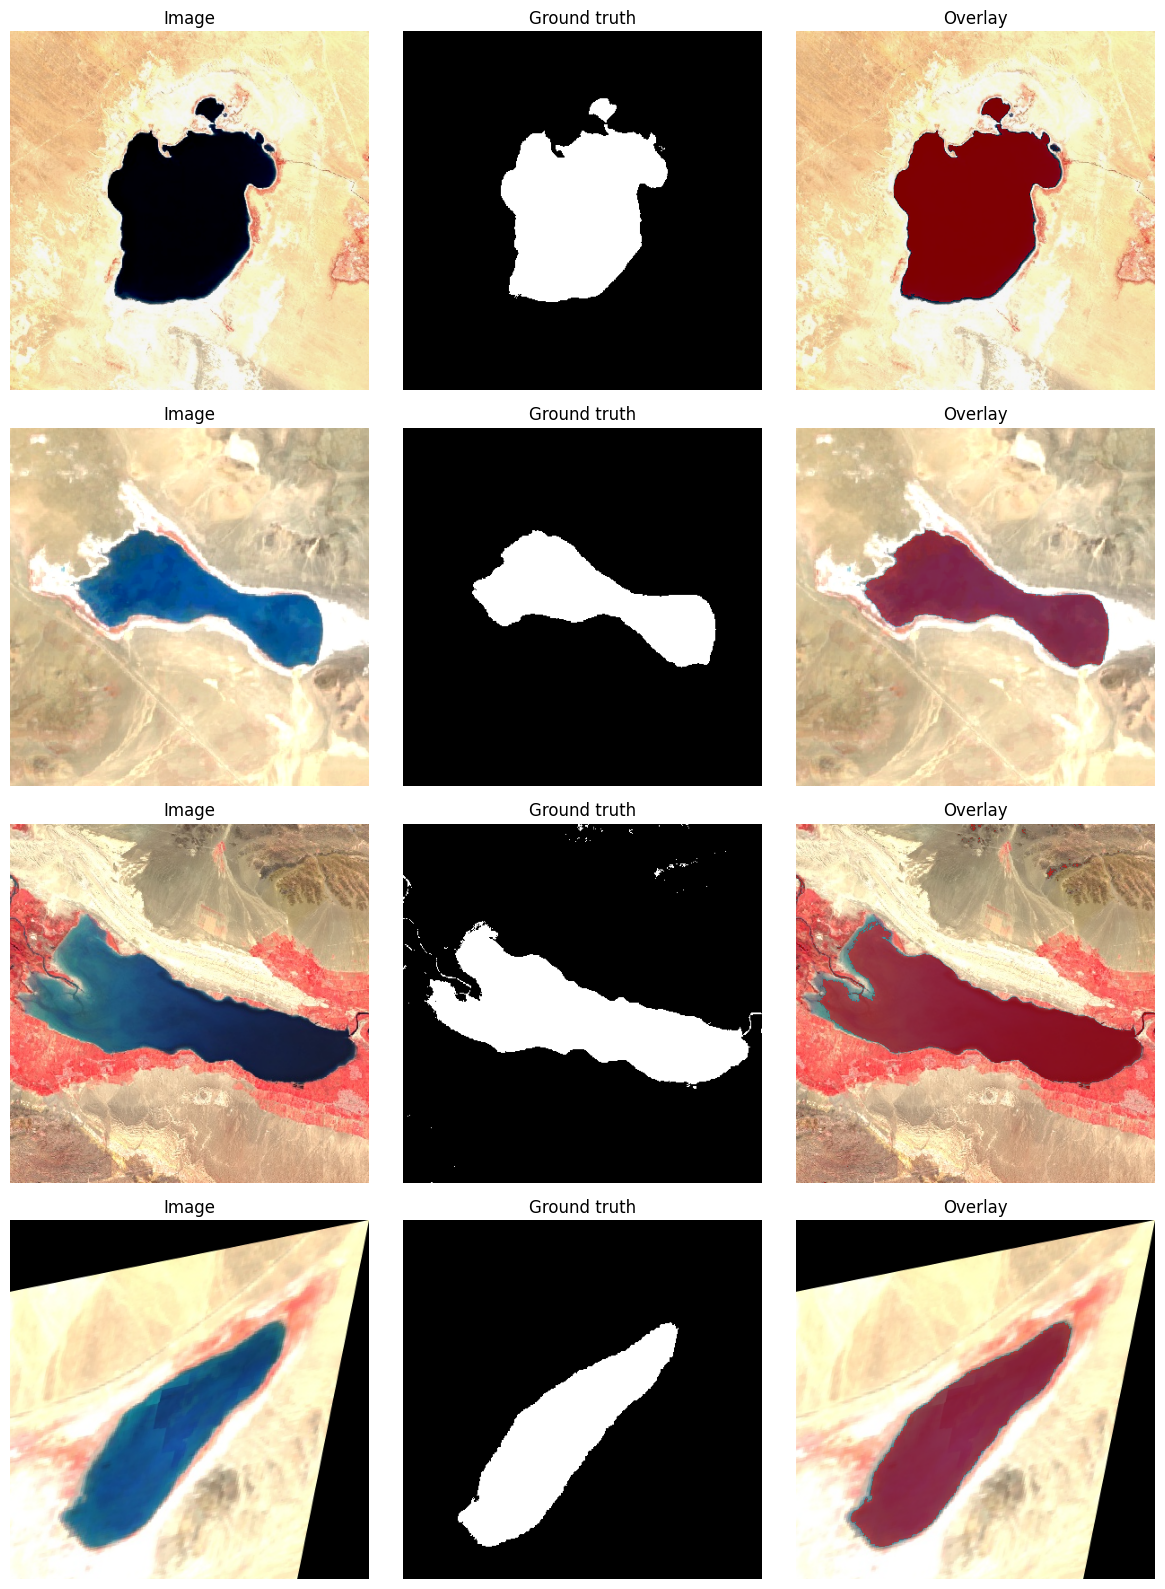

In [9]:
def show_batch(X, y, pred=None, n=4, thr=0.5):
    n = min(n, len(X)); cols = 4 if pred is not None else 3
    fig, axes = plt.subplots(n, cols, figsize=(4 * cols, 4 * n)); axes = np.atleast_2d(axes)
    for i in range(n):
        img = np.clip(X[i] / 255.0, 0, 1)
        axes[i, 0].imshow(img); axes[i, 0].set_title('Image')
        axes[i, 1].imshow(y[i, ..., 0], cmap='gray'); axes[i, 1].set_title('Ground truth')
        if pred is None:
            axes[i, 2].imshow(img); axes[i, 2].imshow(np.ma.masked_where(y[i, ..., 0] == 0, y[i, ..., 0]), alpha=0.5, cmap='autumn')
            axes[i, 2].set_title('Overlay')
        else:
            pm = pred[i, ..., 0] > thr
            axes[i, 2].imshow(pm, cmap='gray'); axes[i, 2].set_title(f'Prediction (thr={thr:.2f})')
            axes[i, 3].imshow(img); axes[i, 3].imshow(np.ma.masked_where(~pm, pm), alpha=0.5, cmap='autumn')
            axes[i, 3].set_title('Pred overlay')
        for a in axes[i]: a.axis('off')
    plt.tight_layout(); plt.show()

show_batch(*train_seq[0], n=4)   # augmented training samples

# Model: DeepLabV3+ (ResNet50, output stride 16)

In [10]:
reg = tf.keras.utils.register_keras_serializable(package='glof')

@reg
class ResNetPreprocess(Layer):
    """Keras ResNet50 ImageNet weights expect BGR, mean-subtracted, 0-255 input."""
    def call(self, x):
        x = tf.reverse(x, axis=[-1])
        return x - tf.constant([103.939, 116.779, 123.68], dtype=x.dtype)

@reg
class ConvBlock(Layer):
    def __init__(self, filters=256, kernel_size=3, dilation_rate=1, **kwargs):
        super().__init__(**kwargs)
        self.filters, self.kernel_size, self.dilation_rate = filters, kernel_size, dilation_rate
        self.net = Sequential([
            Conv2D(filters, kernel_size=kernel_size, padding='same', dilation_rate=dilation_rate,
                   use_bias=False, kernel_initializer='he_normal'),
            BatchNormalization(),
            ReLU(),
        ])

    def call(self, X):
        return self.net(X)

    def get_config(self):
        return {**super().get_config(), 'filters': self.filters,
                'kernel_size': self.kernel_size, 'dilation_rate': self.dilation_rate}

def AtrousSpatialPyramidPooling(X, rates=(2, 4, 6), filters=256):
    # 400px input at output stride 16 -> 25x25 map, so the usual (6,12,18) rates would mostly
    # sample zero padding. Use rates that fit the feature-map size.
    _, H, W, _ = X.shape
    image_pool = AveragePooling2D(pool_size=(H, W), name='ASPP-AvgPool')(X)
    image_pool = ConvBlock(filters, kernel_size=1, name='ASPP-ImagePool-CB')(image_pool)
    image_pool = UpSampling2D(size=(H, W), name='ASPP-ImagePool-UpSample')(image_pool)
    branches = [image_pool, ConvBlock(filters, kernel_size=1, name='ASPP-CB-1')(X)]
    branches += [ConvBlock(filters, kernel_size=3, dilation_rate=r, name=f'ASPP-CB-{r}')(X) for r in rates]
    out = ConvBlock(filters, kernel_size=1, name='ASPP-Net')(Concatenate(name='ASPP-Combine')(branches))
    return Dropout(0.1, name='ASPP-Dropout')(out)

def build_deeplabv3plus(image_size=IMAGE_SIZE, aspp_rates=(2, 4, 6), weights='imagenet'):
    inp = Input(shape=(image_size, image_size, 3), name='InputLayer')
    x = ResNetPreprocess(name='ResNetPreprocess')(inp)

    backbone = ResNet50(include_top=False, weights=weights, input_shape=(image_size, image_size, 3))
    feat_model = Model(backbone.input,
                       [backbone.get_layer('conv2_block3_out').output,   # stride 4  (low-level)
                        backbone.get_layer('conv4_block6_out').output],  # stride 16 (high-level)
                       name='resnet50_features')
    low, high = feat_model(x)

    aspp = AtrousSpatialPyramidPooling(high, rates=aspp_rates)
    aspp = UpSampling2D(size=(low.shape[1] // aspp.shape[1], low.shape[2] // aspp.shape[2]),
                        interpolation='bilinear', name='ASPP-Upsample')(aspp)
    low = ConvBlock(48, kernel_size=1, name='LLF-ConvBlock')(low)

    f = Concatenate(axis=-1, name='Combine-LLF-ASPP')([aspp, low])
    f = ConvBlock(name='Top-ConvBlock-1')(f)
    f = ConvBlock(name='Top-ConvBlock-2')(f)

    logits = Conv2D(1, kernel_size=1, use_bias=True, name='Logits')(f)          # bias lets it learn the class prior
    logits = UpSampling2D(size=(image_size // logits.shape[1], image_size // logits.shape[2]),
                          interpolation='bilinear', name='Top-UpSample')(logits)
    out = Activation('sigmoid', name='OutputMask')(logits)
    return Model(inp, out, name='DeepLabV3Plus-ResNet50'), feat_model

# Loss & metrics

In [11]:
@reg
def dice_loss(y_true, y_pred, smooth=1.0):
    y_true = tf.cast(y_true, y_pred.dtype)
    inter = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    denom = tf.reduce_sum(y_true, axis=[1, 2, 3]) + tf.reduce_sum(y_pred, axis=[1, 2, 3])
    return 1.0 - tf.reduce_mean((2.0 * inter + smooth) / (denom + smooth))

@reg
def bce_dice_loss(y_true, y_pred):
    bce = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))
    return bce + dice_loss(y_true, y_pred)

@reg
def dice_coefficient(y_true, y_pred, smooth=1.0):
    """Hard (thresholded @0.5) Dice."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    inter = tf.reduce_sum(y_true * y_pred)
    return (2.0 * inter + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)

def make_metrics():
    # Stateful, dataset-level, thresholded at 0.5 (accuracy dropped: ~87% of pixels are background)
    return [tf.keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5, name='iou'),
            tf.keras.metrics.Precision(thresholds=0.5, name='precision'),
            tf.keras.metrics.Recall(thresholds=0.5, name='recall'),
            dice_coefficient]

# Train (two phases)

In [12]:
model, feat_model = build_deeplabv3plus()
model.summary(show_trainable=True)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DeepLabV3Plus-ResNet50"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ InputLayer        │ (None, 400,     │         0 │ -              │   -   │
│ (InputLayer)      │ 400, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ ResNetPreprocess  │ (None, 400,     │         0 │ InputLayer[0]… │   -   │
│ (ResNetPreproces… │ 400, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ resnet50_features │ [(None, 100,    │ 8,589,184 │ ResNetPreproc… │   Y   │
│ (Functional)      │ 100, 256),      │           │                │       │
│                   │ (None, 25, 25,  │           │                │       │
│                   │ 1024)]          │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ ASPP-AvgPool      │ (None, 1, 1,    │         0 │ resnet50_feat… │   -   │
│ (AveragePooling2… │ 1024)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ ASPP-ImagePool-CB │ (None, 1, 1,    │   263,168 │ ASPP-AvgPool[… │   Y   │
│ (ConvBlock)       │ 256)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ ASPP-ImagePool-U… │ (None, 25, 25,  │         0 │ ASPP-ImagePoo… │   -   │
│ (UpSampling2D)    │ 256)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ ASPP-CB-1         │ (None, 25, 25,  │   263,168 │ resnet50_feat… │   Y   │
│ (ConvBlock)       │ 256)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ ASPP-CB-2         │ (None, 25, 25,  │ 2,360,320 │ resnet50_feat… │   Y   │
│ (ConvBlock)       │ 256)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ ASPP-CB-4         │ (None, 25, 25,  │ 2,360,320 │ resnet50_feat… │   Y   │
│ (ConvBlock)       │ 256)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ ASPP-CB-6         │ (None, 25, 25,  │ 2,360,320 │ resnet50_feat… │   Y   │
│ (ConvBlock)       │ 256)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ ASPP-Combine      │ (None, 25, 25,  │         0 │ ASPP-ImagePoo… │   -   │
│ (Concatenate)     │ 1280)           │           │ ASPP-CB-1[0][… │       │
│                   │                 │           │ ASPP-CB-2[0][… │       │
│                   │                 │           │ ASPP-CB-4[0][… │       │
│                   │                 │           │ ASPP-CB-6[0][… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ ASPP-Net          │ (None, 25, 25,  │   328,704 │ ASPP-Combine[… │   Y   │
│ (ConvBlock)       │ 256)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ ASPP-Dropout      │ (None, 25, 25,  │         0 │ ASPP-Net[0][0] │   -   │
│ (Dropout)         │ 256)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ ASPP-Upsample     │ (None, 100,     │         0 │ ASPP-Dropout[… │   -   │
│ (UpSampling2D)    │ 100, 256)       │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ LLF-ConvBlock     │ (None, 100,     │    12,480 │ resnet50_feat… │   Y   │
│ (ConvBlock)       │ 100, 48)        │           │                │     

 Total params: 17,830,209 (68.02 MB)

 Trainable params: 17,795,425 (67.88 MB)

 Non-trainable params: 34,784 (135.88 KB)

In [13]:
# Phase 1: backbone frozen, train the ASPP + decoder head
feat_model.trainable = False
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=bce_dice_loss, metrics=make_metrics())
hist_head = model.fit(train_seq, validation_data=val_seq, epochs=5)

Epoch 1/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 128s 4s/step - dice_coefficient: 0.7768 - iou: 0.5336 - loss: 0.6582 - precision: 0.5684 - recall: 0.8971 - val_dice_coefficient: 0.2501 - val_iou: 0.1417 - val_loss: 20.0131 - val_precision: 0.1417 - val_recall: 0.9995
Epoch 2/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 578ms/step - dice_coefficient: 0.9219 - iou: 0.8574 - loss: 0.2198 - precision: 0.9136 - recall: 0.9330 - val_dice_coefficient: 0.2948 - val_iou: 0.1712 - val_loss: 8.4068 - val_precision: 0.1713 - val_recall: 0.9972
Epoch 3/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 588ms/step - dice_coefficient: 0.9305 - iou: 0.8727 - loss: 0.1697 - precision: 0.9353 - recall: 0.9288 - val_dice_coefficient: 0.4882 - val_iou: 0.3152 - val_loss: 2.1157 - val_precision: 0.3159 - val_recall: 0.9926
Epoch 4/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 574ms/step - dice_coefficient: 0.9407 - iou: 0.8890 - loss: 0.1426 - precision: 0.9368 - recall: 0.9457 - val_dice_coefficient: 0.7201 - val_iou: 0.5406 - val_loss: 0.9899 - val_precisio

In [14]:
# Phase 2: unfreeze everything and fine-tune with a much lower LR
CKPT = str(MODEL_DIR / 'deeplabv3plus_best.weights.h5')   # lives on Drive, only the best epoch is kept

feat_model.trainable = True
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss=bce_dice_loss, metrics=make_metrics())

callbacks = [
    ModelCheckpoint(CKPT, monitor='val_iou', mode='max', save_best_only=True, save_weights_only=True, verbose=1),
    EarlyStopping(monitor='val_iou', mode='max', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_iou', mode='max', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
]
hist_ft = model.fit(train_seq, validation_data=val_seq, epochs=50, callbacks=callbacks)

model.load_weights(CKPT)                                   # make sure we evaluate the BEST epoch
model.save(MODEL_DIR / 'deeplabv3_50.keras')

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - dice_coefficient: 0.9482 - iou: 0.9032 - loss: 0.1269 - precision: 0.9512 - recall: 0.9472
Epoch 1: val_iou improved from None to 0.87584, saving model to /content/drive/MyDrive/model/deeplabv3plus_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/model/deeplabv3plus_best.weights.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 157s 5s/step - dice_coefficient: 0.9470 - iou: 0.9001 - loss: 0.1315 - precision: 0.9457 - recall: 0.9492 - val_dice_coefficient: 0.9337 - val_iou: 0.8758 - val_loss: 0.1984 - val_precision: 0.8948 - val_recall: 0.9764 - learning_rate: 1.0000e-04
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 774ms/step - dice_coefficient: 0.9510 - iou: 0.9073 - loss: 0.1174 - precision: 0.9624 - recall: 0.9407
Epoch 2: val_iou improved from 0.87584 to 0.90268, saving model to /content/drive/MyDrive/model/deeplabv3plus_best.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/model/deeplabv3plus_best.weights.h5
18

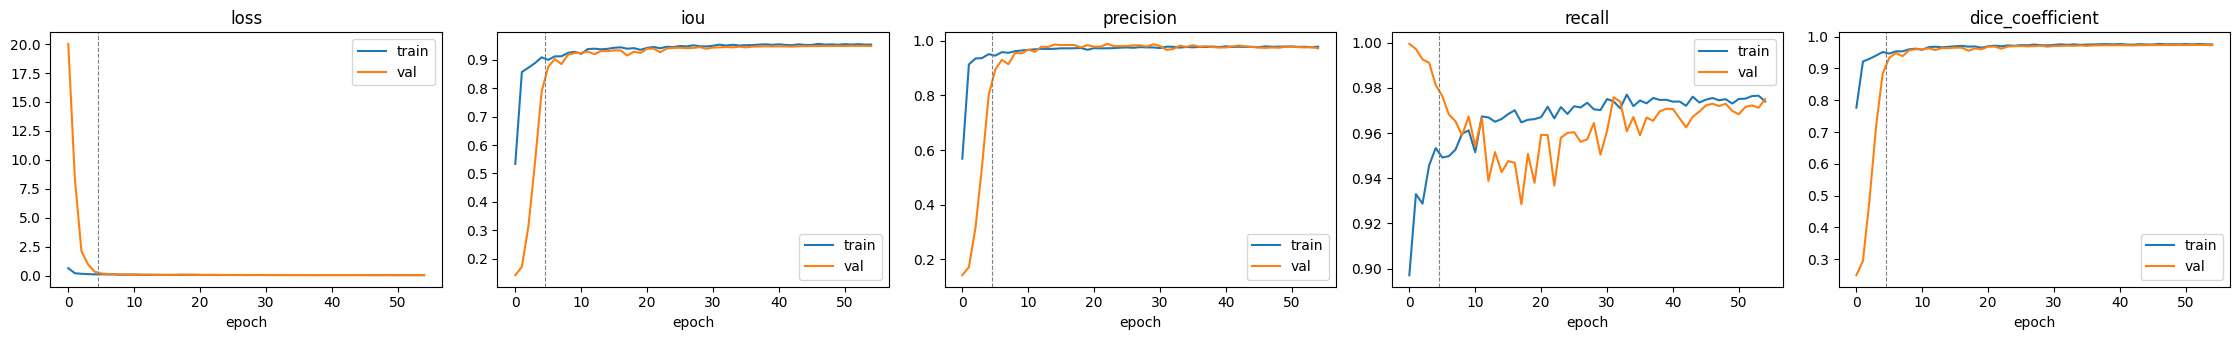

Best epoch 54: val IoU=0.9495 | train IoU=0.9540


In [15]:
def merge_histories(*hs):
    keys = hs[0].history.keys()
    return {k: sum((h.history[k] for h in hs), []) for k in keys}

hist = merge_histories(hist_head, hist_ft)
n_head = len(hist_head.history['loss'])

def plot_history(hist, metrics=('loss', 'iou', 'precision', 'recall', 'dice_coefficient')):
    fig, axes = plt.subplots(1, len(metrics), figsize=(4.5 * len(metrics), 3.5))
    for ax, m in zip(axes, metrics):
        ax.plot(hist[m], label='train'); ax.plot(hist['val_' + m], label='val')
        ax.axvline(n_head - 0.5, color='gray', ls='--', lw=0.8)   # phase 1 -> phase 2
        ax.set_title(m); ax.set_xlabel('epoch'); ax.legend()
    plt.tight_layout(); plt.show()

plot_history(hist)
best = int(np.argmax(hist['val_iou']))
print(f"Best epoch {best + 1}: val IoU={hist['val_iou'][best]:.4f} | train IoU={hist['iou'][best]:.4f}")

# Evaluation on the held-out test set
Threshold is tuned on **val only**, then applied once to **test**. NDWI baselines are scored on the same test tiles.

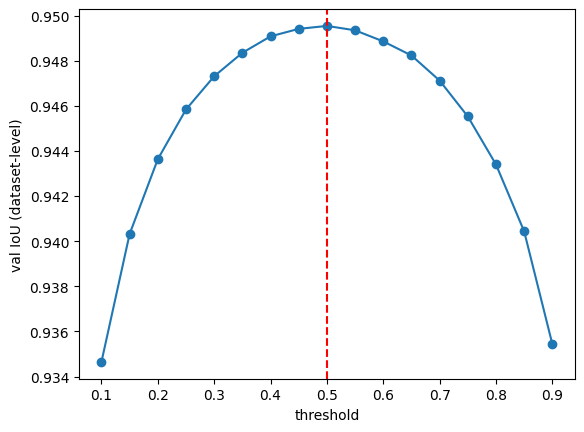

Best threshold on val: 0.50


In [16]:
def predict_probs(seq):
    return model.predict(seq, verbose=0)

def stack_masks(ds):
    return np.stack([ds[i][1] for i in range(len(ds))])

val_probs,  val_gt  = predict_probs(val_seq),  stack_masks(val_ds)
test_probs, test_gt = predict_probs(test_seq), stack_masks(test_ds)

def dataset_iou(probs, gts, thr):
    p, g = probs[..., 0] > thr, gts[..., 0] > 0.5
    return (p & g).sum() / ((p | g).sum() + 1e-8)

thrs = np.arange(0.1, 0.91, 0.05)
val_ious = [dataset_iou(val_probs, val_gt, t) for t in thrs]
best_thr = float(thrs[int(np.argmax(val_ious))])
plt.plot(thrs, val_ious, marker='o'); plt.axvline(best_thr, color='r', ls='--')
plt.xlabel('threshold'); plt.ylabel('val IoU (dataset-level)'); plt.show()
print(f'Best threshold on val: {best_thr:.2f}')

In [17]:
# Fair comparison: every method scored per-image on the SAME test tiles
test_imgs_arr = np.stack([test_ds[i][0] for i in range(len(test_ds))])

# Otsu threshold for NDWI is fit on val pixels only
val_ndwi = np.concatenate([compute_ndwi(val_ds[i][0]).ravel() for i in range(len(val_ds))])
ndwi_otsu = float(threshold_otsu(val_ndwi))

test_ndwi = [compute_ndwi(im) for im in test_imgs_arr]
methods = {
    'NDWI (thr = 0)':                 [ndwi_to_mask(n, 0.0) for n in test_ndwi],
    f'NDWI (Otsu on val = {ndwi_otsu:.2f})': [ndwi_to_mask(n, ndwi_otsu) for n in test_ndwi],
    'DeepLabV3+ (thr = 0.50)':        [(p[..., 0] > 0.5).astype(np.float32) for p in test_probs],
    f'DeepLabV3+ (thr = {best_thr:.2f}, tuned on val)': [(p[..., 0] > best_thr).astype(np.float32) for p in test_probs],
}

per_image = {}
rows = []
for name, preds in methods.items():
    df = pd.DataFrame([compute_metrics(p, g[..., 0]) for p, g in zip(preds, test_gt)])
    per_image[name] = df
    rows.append({'Method': name, **{f'{c}': f'{df[c].mean():.4f} ± {df[c].std():.4f}' for c in df.columns}})
print(f'Test set: {len(test_ds)} images (per-image mean ± std)')
pd.DataFrame(rows).set_index('Method')

Test set: 62 images (per-image mean ± std)


,IoU,Precision,Recall,F1
Method,,,,
NDWI (thr = 0),0.7355 ± 0.2061,0.7520 ± 0.2099,0.9765 ± 0.0617,0.8295 ± 0.1558
NDWI (Otsu on val = 0.29),0.8458 ± 0.2276,0.9281 ± 0.1785,0.8851 ± 0.2239,0.8924 ± 0.2027
DeepLabV3+ (thr = 0.50),0.9536 ± 0.0429,0.9797 ± 0.0227,0.9719 ± 0.0268,0.9757 ± 0.0235
"DeepLabV3+ (thr = 0.50, tuned on val)",0.9536 ± 0.0429,0.9797 ± 0.0227,0.9719 ± 0.0268,0.9757 ± 0.0235


           IoU  Precision  Recall
size                             
small   0.9379     0.9746  0.9600
medium  0.9566     0.9789  0.9761
large   0.9664     0.9857  0.9799
Worst test tiles: ['image_327.png', 'image_94.png', 'image_129.png', 'image_199.png'] [0.77, 0.86, 0.869, 0.869]


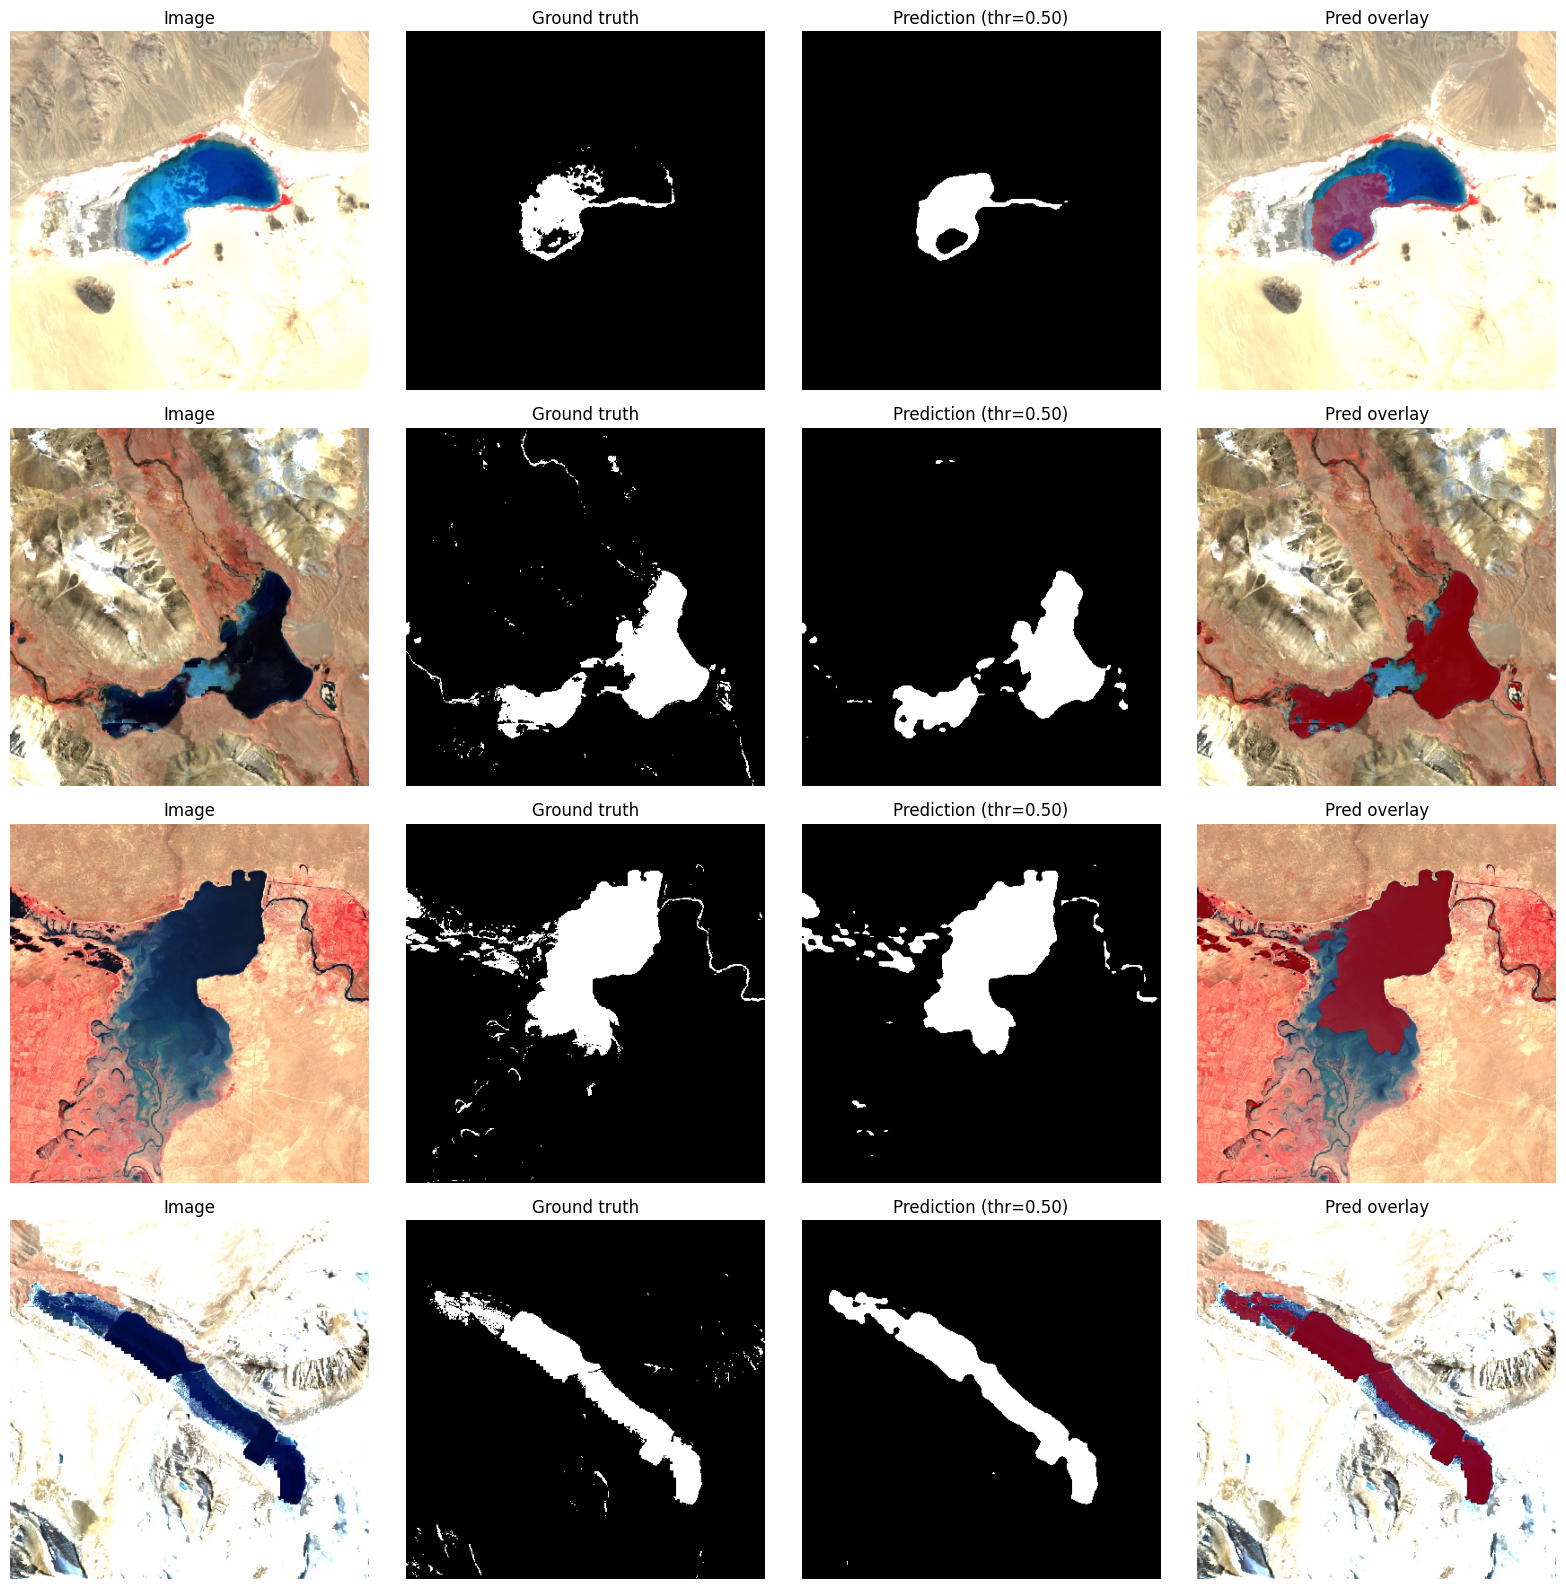

In [18]:
# Where does the model fail? IoU by lake size, then the worst tiles.
final_name = list(methods)[-1]
res = per_image[final_name].copy()
res['water_%'] = test_gt[..., 0].mean(axis=(1, 2)) * 100
res['size'] = pd.qcut(res['water_%'], 3, labels=['small', 'medium', 'large'])
print(res.groupby('size', observed=True)[['IoU', 'Precision', 'Recall']].mean().round(4))

worst = res['IoU'].nsmallest(4).index.to_numpy()
print('Worst test tiles:', [test_imgs[i].name for i in worst], res.loc[worst, 'IoU'].round(3).tolist())
show_batch(test_imgs_arr[worst], test_gt[worst], pred=test_probs[worst], n=4, thr=best_thr)

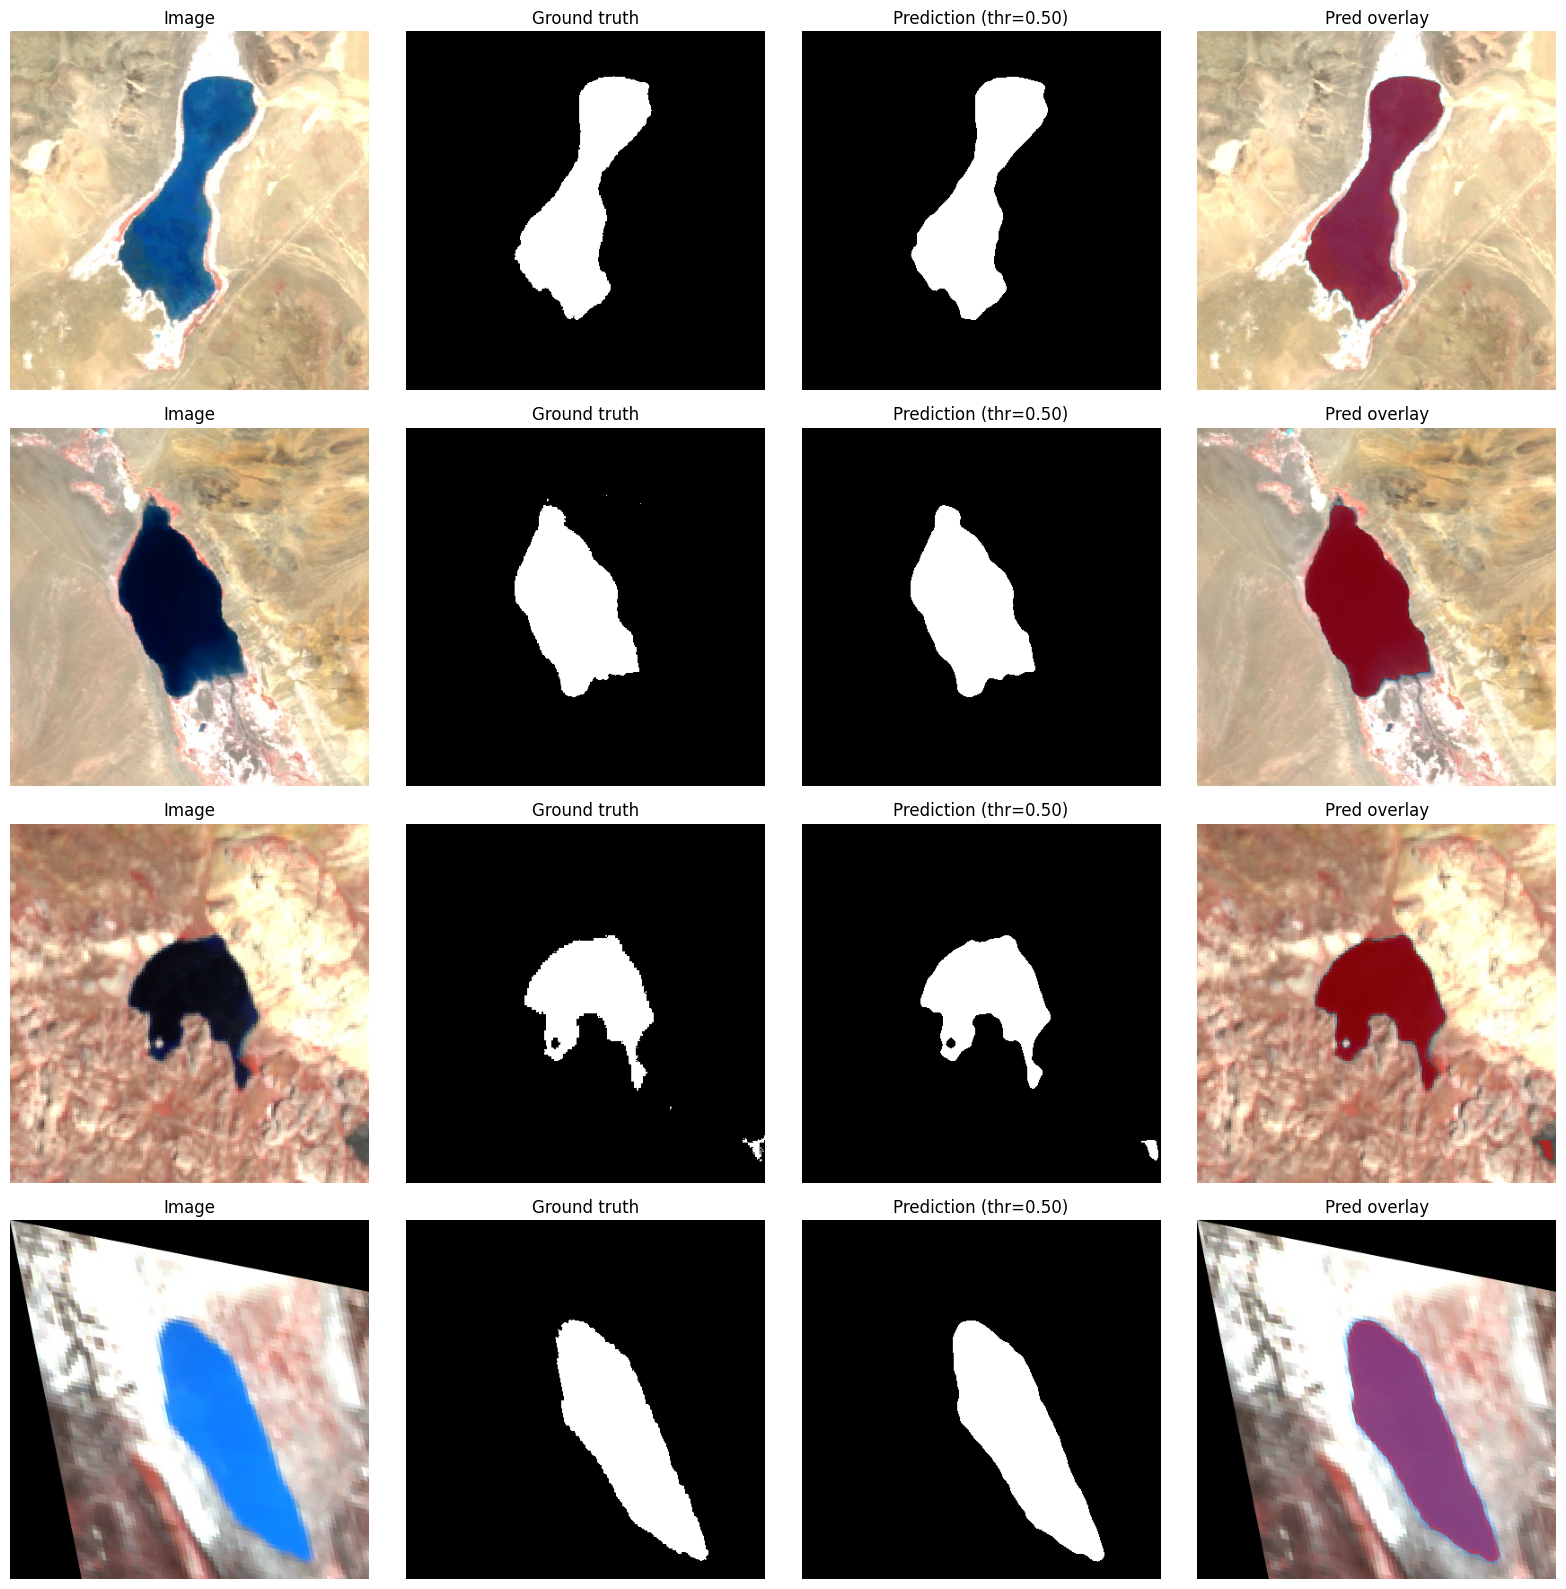

In [19]:
# Qualitative check on random test tiles
sel = np.random.default_rng(SEED).choice(len(test_ds), size=4, replace=False)
show_batch(test_imgs_arr[sel], test_gt[sel], pred=test_probs[sel], n=4, thr=best_thr)